In [114]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [115]:
df = pd.read_csv('nhl_players.csv')
df.head()

,season,player_id,firstName,lastName,timeOnIce,assists,goals,shots,penaltyMinutes
0,20002001,8444894,Greg,Adams,51806,12,11,66,10
1,20002001,8444919,Tommy,Albelin,96465,19,1,69,22
2,20002001,8445000,Dave,Andreychuk,53248,13,20,119,32
3,20002001,8445176,Donald,Audette,90473,45,34,225,76
4,20002001,8445266,Murray,Baron,95471,8,3,56,63


In [116]:
'''
I expect goals to have a positive correlation with assists, as with timeOnIce and shots. Naturally skilled
players will get assists as well as goals. More time on ice and more shots mean more opportunities to score.
I expect penaltyMinutes to have little correlation with goal scoring, positive or negative.
'''

'\nI expect goals to have a positive correlation with assists, as with timeOnIce and shots. Naturally skilled\nplayers will get assists as well as goals. More time on ice and more shots mean more opportunities to score.\nI expect penaltyMinutes to have little correlation with goal scoring, positive or negative.\n'

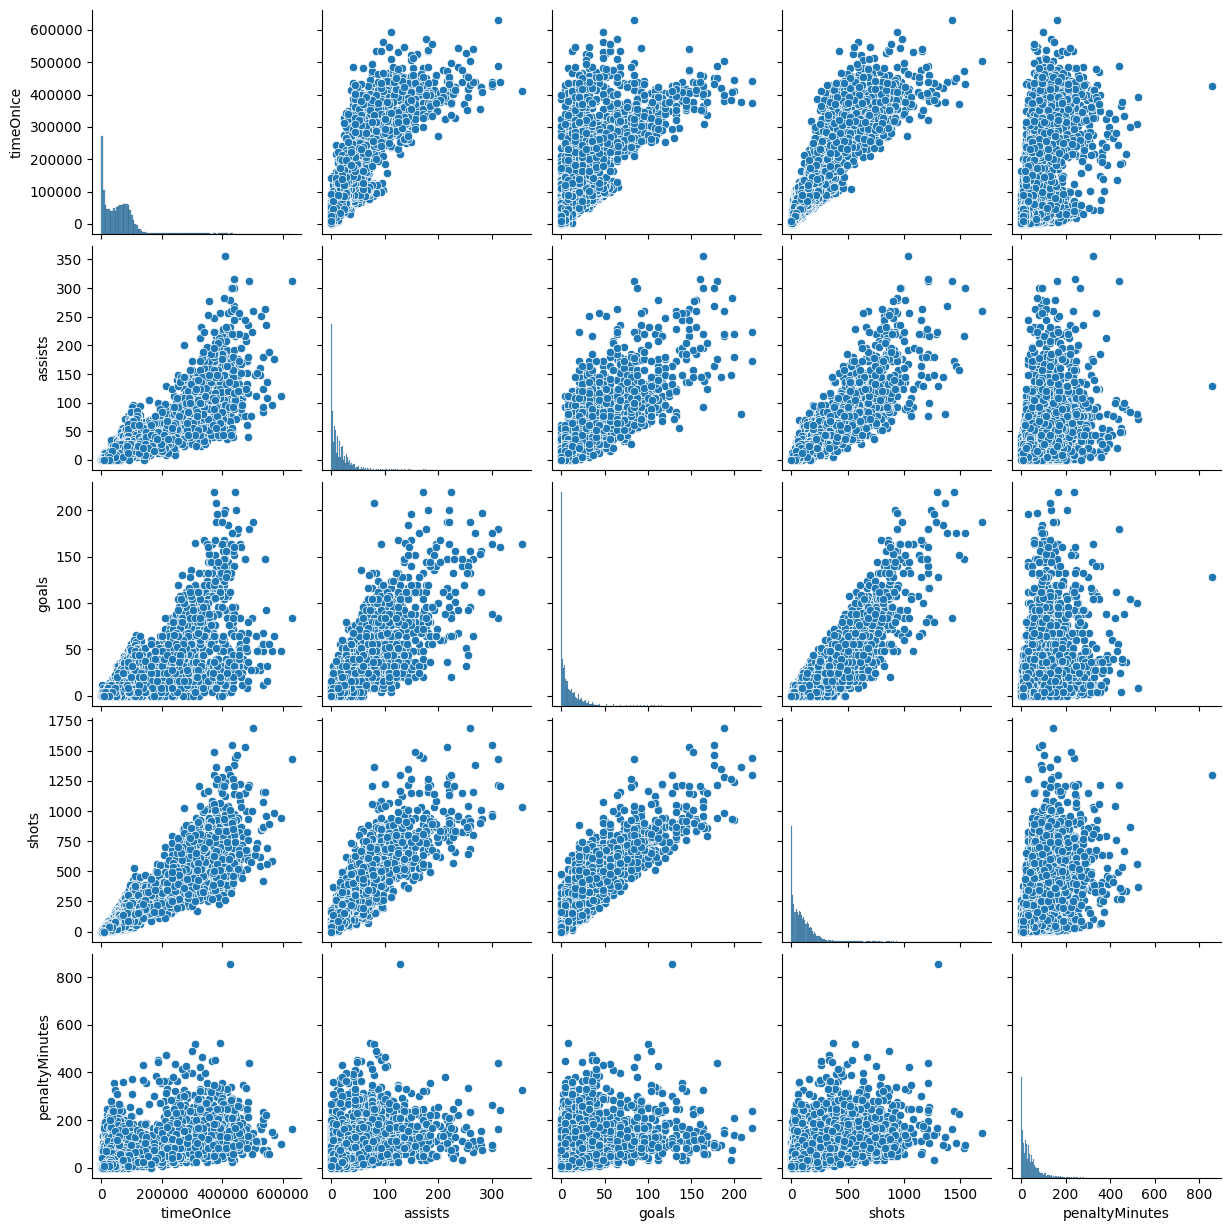

In [117]:
sns.pairplot(df.drop(['player_id', 'season'], axis=1))

In [118]:
'''
Initially what jumps out at me is that timeOnIce is positively correlated with assists, goals, and shots, but
slightly less so than goals. This makes intuitive sense, assists and shots are easier to obtain, but I hadn't
predicted it. Assists are positively correlated with goals, as predicted. Goals seem to be most positively
correlated with shots.
'''

"\nInitially what jumps out at me is that timeOnIce is positively correlated with assists, goals, and shots, but\nslightly less so than goals. This makes intuitive sense, assists and shots are easier to obtain, but I hadn't\npredicted it. Assists are positively correlated with goals, as predicted. Goals seem to be most positively\ncorrelated with shots.\n"

Text(0.5, 1.0, 'Goals vs. Ice Time w/ Shots Hue')

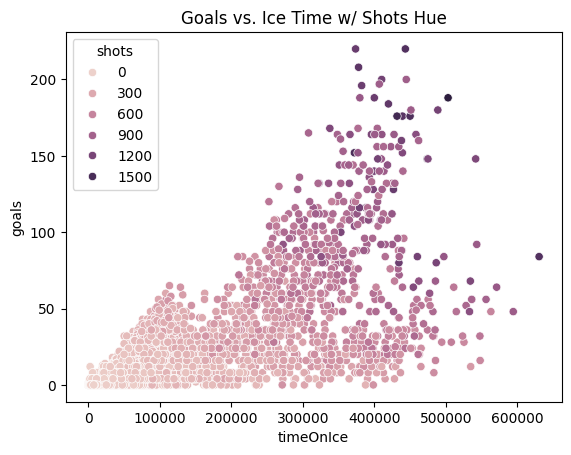

In [119]:
sns.scatterplot(x='timeOnIce', y='goals', hue='shots', data=df)
plt.title("Goals vs. Ice Time w/ Shots Hue")

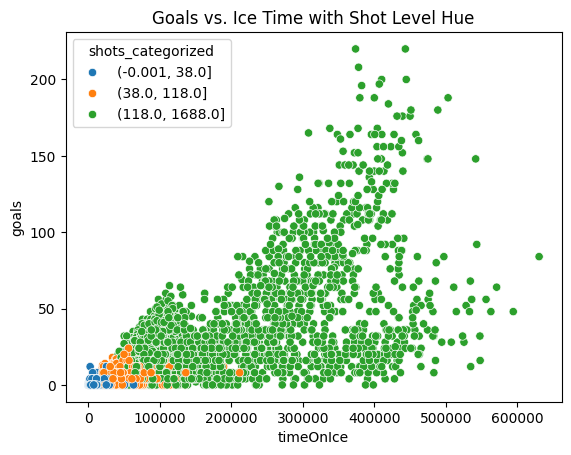

In [120]:
df['shots_categorized'] = pd.qcut(df['shots'], 3)
sns.scatterplot(x='timeOnIce', y='goals', hue='shots_categorized', data=df)
plt.title("Goals vs. Ice Time with Shot Level Hue")
df = df.drop(columns=['shots_categorized'])

In [121]:
'''
These figures reveal a strong correlation between all three features timeOnIce, shots, and goals.
At the same time, it reveals that the vast majority of NHL players get very little shots, goals,
or playing time in a year. We can also see that, although it is possible to rack up ice time without
shooting many shots or scoring many goals, you cannot have a lot of shots or a lot of goals without ice time.
'''

'\nThese figures reveal a strong correlation between all three features timeOnIce, shots, and goals.\nAt the same time, it reveals that the vast majority of NHL players get very little shots, goals,\nor playing time in a year. We can also see that, although it is possible to rack up ice time without\nshooting many shots or scoring many goals, you cannot have a lot of shots or a lot of goals without ice time.\n'

In [122]:
n = len(df)
p = len(df.columns.drop(['player_id', 'firstName', 'lastName', 'season', 'goals'])) + 1

print(f"n = {n}")
print(f"p = {p}")

n = 16787
p = 5


In [123]:
'''
In order, I expect a expect a positive coefficient between our target feature goals
with input features timeOnIce, assists, and shots.
I expect no coefficient between goals and penaltyMinutes.
'''


'\nIn order, I expect a expect a positive coefficient between our target feature goals\nwith input features timeOnIce, assists, and shots.\nI expect no coefficient between goals and penaltyMinutes.\n'

In [124]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['player_id', 'firstName', 'season', 'lastName', 'goals'])
X['bias'] = np.ones(X.shape[0])
y = df["goals"]

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)
X.head()

Shape of X: (16787, 5)
Shape of y: (16787,)


,timeOnIce,assists,shots,penaltyMinutes,bias
0,51806,12,66,10,1.0
1,96465,19,69,22,1.0
2,53248,13,119,32,1.0
3,90473,45,225,76,1.0
4,95471,8,56,63,1.0


In [125]:
rk = np.linalg.matrix_rank(X)
print(f'The rank of our matrix X is {rk}.')

The rank of our matrix X is 5.


In [126]:
'''
As is typical, rk = p for our matrix. Had this not been the case, then X^TX would have been non-invertible, making the Least Squares estimate
uncomputable.
'''

'\nAs is typical, rk = p for our matrix. Had this not been the case, then X^TX would have been non-invertible, making the Least Squares estimate \nuncomputable.\n'

In [127]:
'''
θ^ = (X^TX)^(-1)X^Ty
'''

XTX = np.dot(np.transpose(X_train), X_train)
XTXINV = np.linalg.inv(XTX)
ls = np.dot(np.dot(XTXINV, np.transpose(X_train)), y_train)

print(f'Coefficients: {ls}')

Coefficients: [-1.21153440e-04  1.69626886e-01  1.33189887e-01  4.38332665e-03
  3.03544838e-01]


In [128]:
'''
We have a very slight, almost 0 negative coeffiecient on timeOnIce. I had predicted a positive coefficient, but once you factor in that
least squares is computing the relationship between timeOnIce and goals while holding the other features constant, this makes sense. If I know a
player scores and shoots a lot, their ice time will not tell me anything more about them. As expected assists and shots had a significant positive
coefficient. Penalty minutes had a slightly positive - almost zero coeffiecient. This is not surprising, penalty minutes would not indicate
that a player can score, but also would not indicate they cannot.
'''

' \nWe have a very slight, almost 0 negative coeffiecient on timeOnIce. I had predicted a positive coefficient, but once you factor in that\nleast squares is computing the relationship between timeOnIce and goals while holding the other features constant, this makes sense. If I know a \nplayer scores and shoots a lot, their ice time will not tell me anything more about them. As expected assists and shots had a significant positive\ncoefficient. Penalty minutes had a slightly positive - almost zero coeffiecient. This is not surprising, penalty minutes would not indicate\nthat a player can score, but also would not indicate they cannot.\n'

In [129]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred_train = X_train @ ls
y_pred_test = X_test @ ls

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'RMSE on training set: {rmse_train:.2f}')
print(f'R^2 on training set: {r2_train:.2f}')
print(f'RMSE on test set: {rmse_test:.2f}')
print(f'R^2 on test set: {r2_test:.2f}')


RMSE on training set: 6.74
R^2 on training set: 0.86
RMSE on test set: 6.24
R^2 on test set: 0.86


In [130]:
'''
On the test set, we had a RMSE of about 6.24. In the context of an entire 82 game season, being off by 6 goals is a very acceptable error.
Overall, we provide a pretty good estimate of the target variable. Our R^2 value essentially says that our input features explain 86% of the
variation; that is a pretty good picture.
'''

'\nOn the test set, we had a RMSE of about 6.24. In the context of an entire 82 game season, being off by 6 goals is a very acceptable error.\nOverall, we provide a pretty good estimate of the target variable. Our R^2 value essentially says that our input features explain 86% of the \nvariation; that is a pretty good picture.\n'

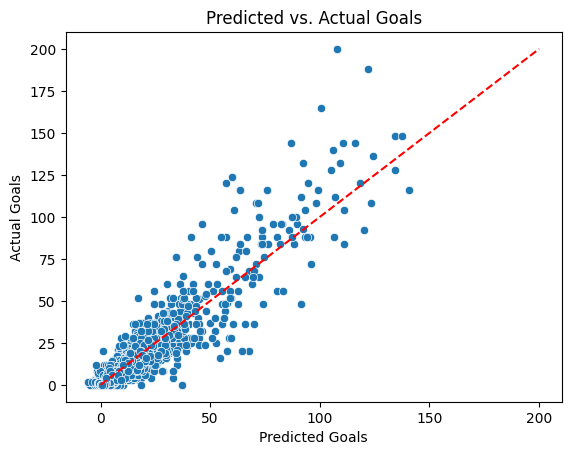

In [131]:
sns.scatterplot(x=y_pred_test, y=y_test)
plt.xlabel("Predicted Goals")
plt.ylabel("Actual Goals")
plt.title("Predicted vs. Actual Goals")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

In [132]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)
y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'RMSE on training set: {rmse_train:.2f}')
print(f'R^2 on training set: {r2_train:.2f}')
print(f'RMSE on test set: {rmse_test:.2f}')
print(f'R^2 on test set: {r2_test:.2f}')


RMSE on training set: 6.74
R^2 on training set: 0.86
RMSE on test set: 6.24
R^2 on test set: 0.86


In [133]:
'''
The results are the exact same. Clearly the math is the same as well under the hood.
'''

'\nThe results are the exact same. Clearly the math is the same as well under the hood.\n'